# Bottleneck breakdown (GEMMs / Attn / Others)

Reads `bottleneck_experimental_analysis.xlsx`, converts the per-row (GEMMs, Attn, Others) microsecond columns to percentages, and renders a stacked-bar plot — one bar per context length.

In [6]:
from pathlib import Path
import re
import zipfile
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

XLSX_PATH = Path(
    "./nvidia_toolkit_data/"
    "bottleneck_experimental_analysis/bottleneck_experimental_analysis.xlsx"
)
FIGURES_DIR = Path("./figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUT_PNG = FIGURES_DIR / "bottleneck_experimental_analysis.png"

In [7]:
def _read_xlsx_via_zip(path: Path) -> pd.DataFrame:
    """Tiny pure-stdlib xlsx reader so this notebook works even when openpyxl isn't installed."""
    ns = {"s": "http://schemas.openxmlformats.org/spreadsheetml/2006/main"}
    with zipfile.ZipFile(path) as z:
        shared = []
        if "xl/sharedStrings.xml" in z.namelist():
            root = ET.fromstring(z.read("xl/sharedStrings.xml"))
            for si in root.findall("s:si", ns):
                shared.append(
                    "".join(
                        t.text or ""
                        for t in si.iter(
                            "{http://schemas.openxmlformats.org/spreadsheetml/2006/main}t"
                        )
                    )
                )
        sheet_name = next(
            n for n in z.namelist() if n.startswith("xl/worksheets/sheet") and n.endswith(".xml")
        )
        root = ET.fromstring(z.read(sheet_name))
        rows = []
        for row in root.findall(".//s:row", ns):
            cells = {}
            for c in row.findall("s:c", ns):
                ref = c.attrib.get("r", "")
                col_letters = re.match(r"[A-Z]+", ref).group(0)
                col_idx = 0
                for ch in col_letters:
                    col_idx = col_idx * 26 + (ord(ch) - ord("A") + 1)
                col_idx -= 1
                t = c.attrib.get("t")
                v = c.find("s:v", ns)
                if t == "s" and v is not None:
                    cells[col_idx] = shared[int(v.text)]
                elif v is not None:
                    cells[col_idx] = v.text
            if cells:
                width = max(cells) + 1
                rows.append([cells.get(i, "") for i in range(width)])
    header, *body = rows
    df = pd.DataFrame(body, columns=header)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col])
    return df


def load_data(path: Path) -> pd.DataFrame:
    try:
        return pd.read_excel(path)
    except ImportError:
        return _read_xlsx_via_zip(path)


df = load_data(XLSX_PATH)
df

,context_len,GEMMs (us),Attn (us),Others (us)
0,500,134.657,35.040,5.617
1,1000,134.657,65.888,7.916
2,1500,134.368,96.897,8.098
3,2000,133.601,130.112,8.114
4,2500,135.232,157.153,7.804
5,3000,132.832,192.033,8.041
6,3500,133.985,220.737,7.909
7,4000,131.168,254.946,8.222


In [8]:
# Step 2: convert microseconds to per-row percentages of total time.
components = ["GEMMs (us)", "Attn (us)", "Others (us)"]
totals = df[components].sum(axis=1)
pct = df[components].div(totals, axis=0) * 100.0
pct.columns = ["GEMMs", "Attn", "Others"]
pct.insert(0, "context_len", df["context_len"].astype(int).to_numpy())
pct

,context_len,GEMMs,Attn,Others
0,500,76.809040,19.986995,3.203965
1,1000,64.595776,31.606871,3.797353
2,1500,56.135660,40.481194,3.383146
3,2000,49.149275,47.865738,2.984987
4,2500,45.048952,52.351352,2.599696
5,3000,39.900753,57.683851,2.415397
6,3500,36.948027,60.870968,2.181005
7,4000,33.263004,64.651972,2.085024


In [11]:
# ---- Plot configuration (tweak these knobs) ----
BAR_WIDTH = 0.4          # width of each stacked bar
GROUP_GAP = 0.5          # horizontal gap between neighboring bars (groups)

FONTSIZE_XLABEL = 14     # "Context length" axis label
FONTSIZE_YLABEL = 14     # "Percentage (%)" axis label
FONTSIZE_XTICKS = 14     # x-tick labels (the 8 context lengths)
FONTSIZE_YTICKS = 14     # y-tick labels
FONTSIZE_XTITLE = 14     # axis-title font for x (== xlabel weight tuning)
FONTSIZE_YTITLE = 14     # axis-title font for y
FONTSIZE_LEGEND = 14

# Colors per requirement: bottom=Others, middle=GEMMs, top=Attn.
COLOR_OTHERS = "#7fc4f5"
COLOR_GEMMS = "#b8e08c"
COLOR_ATTN = "#ffced3"

# Horizontal reference line marking the 50% mark.
HLINE_Y = 50
HLINE_COLOR = "gray"
HLINE_LINESTYLE = "--"
HLINE_LINEWIDTH = 1.0

FIG_DPI = 300

saved -> ./figures/bottleneck_experimental_analysis.png


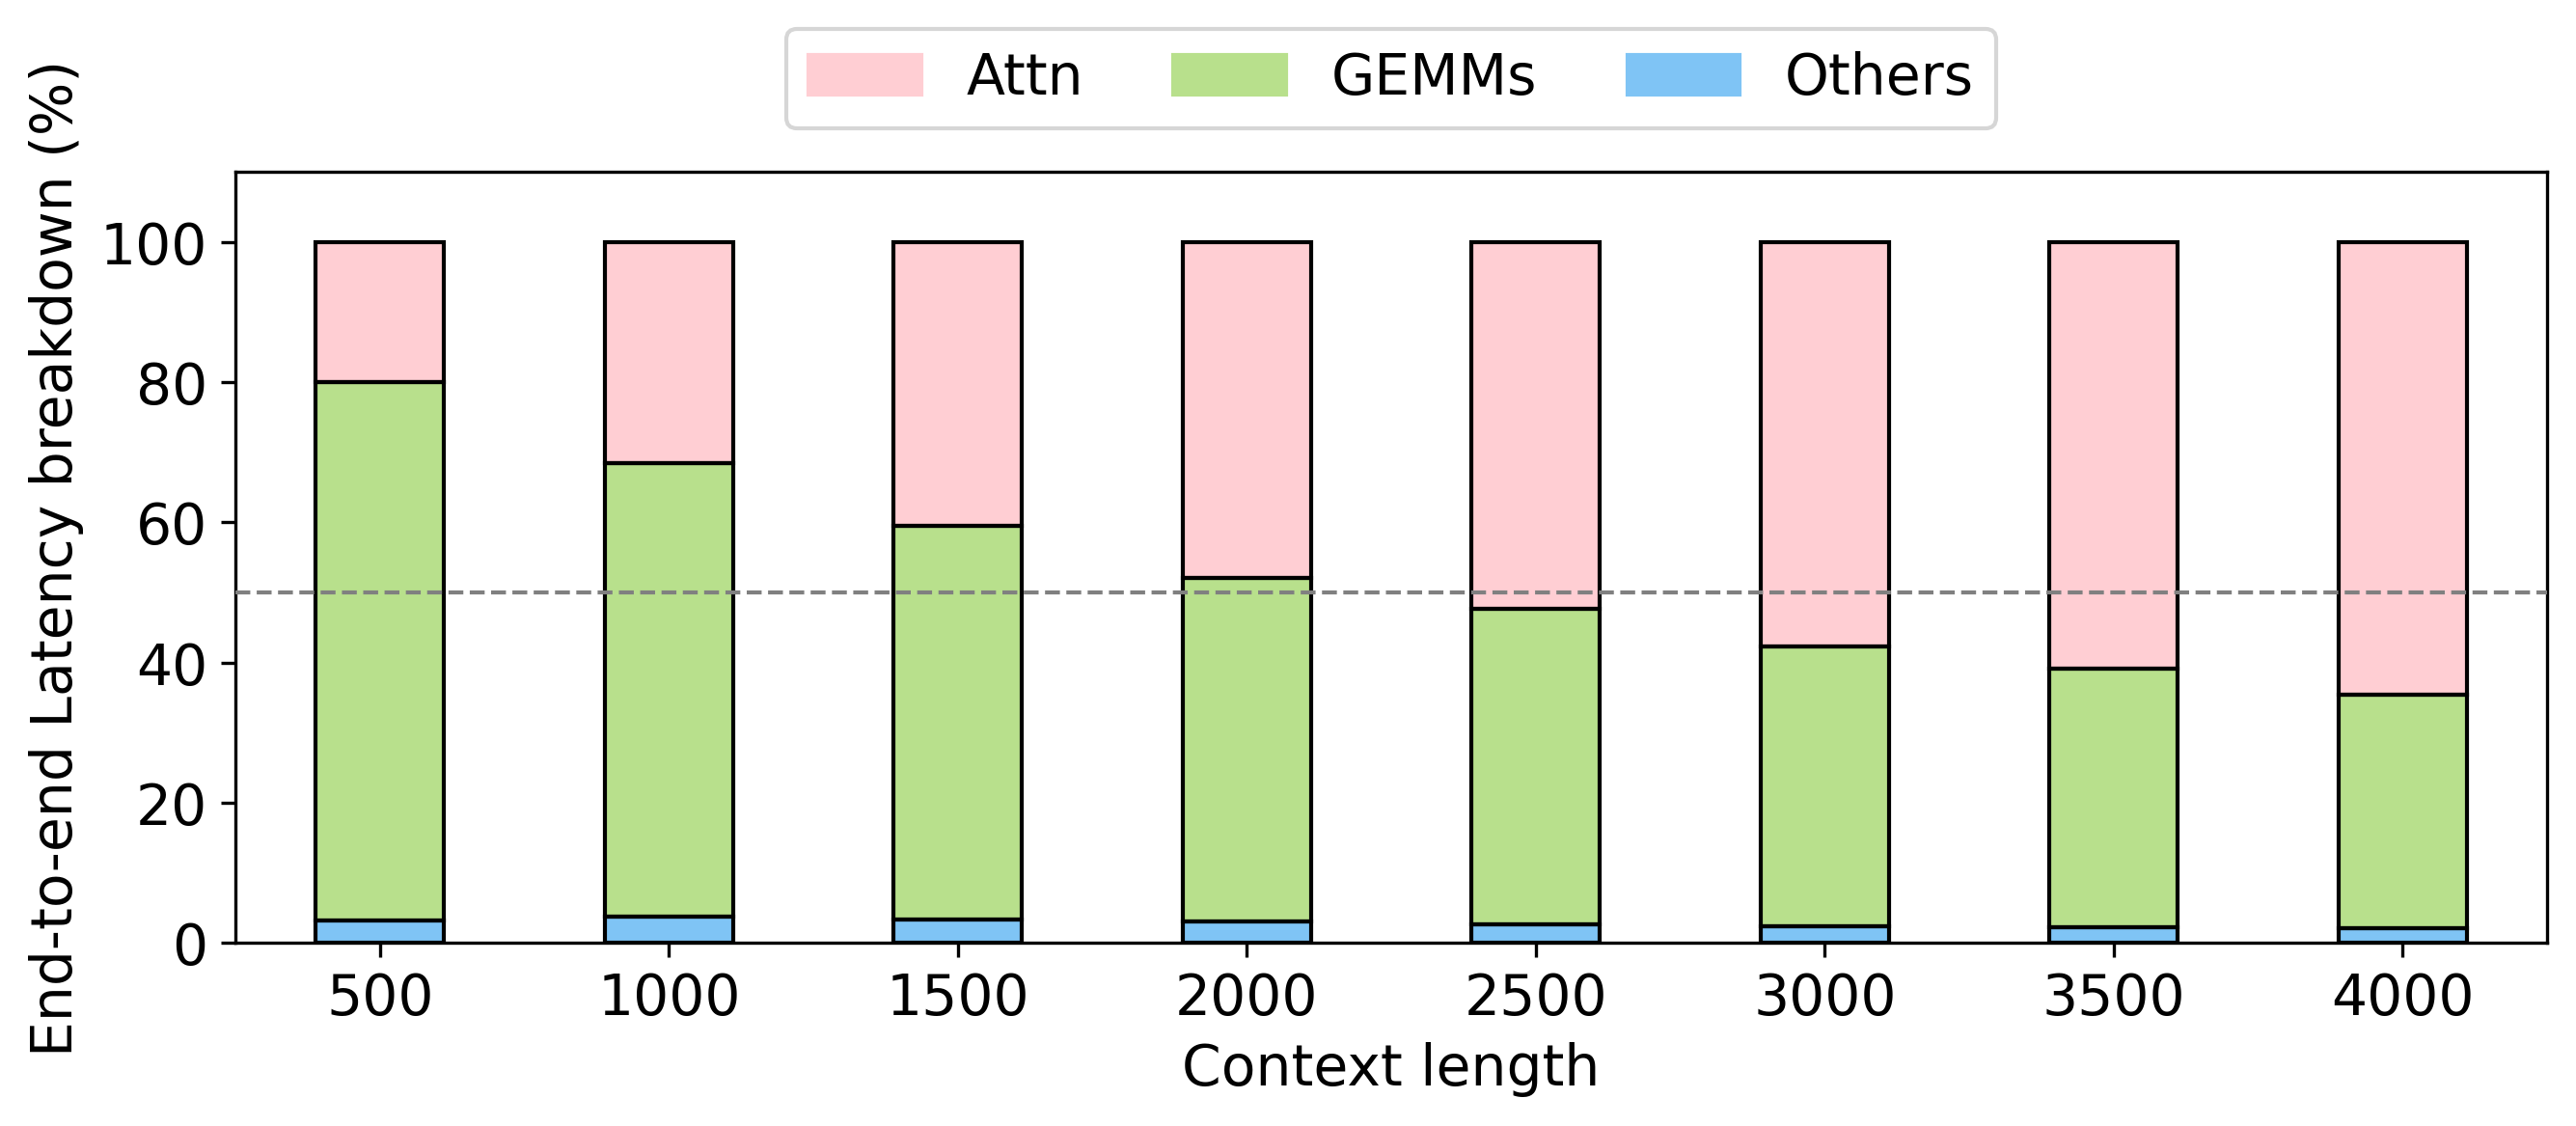

In [12]:
x_labels = pct["context_len"].tolist()
x = np.arange(len(x_labels)) * (BAR_WIDTH + GROUP_GAP)

others = pct["Others"].to_numpy()
gemms = pct["GEMMs"].to_numpy()
attn = pct["Attn"].to_numpy()

fig, ax = plt.subplots(figsize=(9, 4), dpi=FIG_DPI)

# Pass 1: colored hatch on white face, no visible border (linewidth=0).
# These carry the legend label so the legend swatches show the stripes.
ax.bar(
    x, others, width=BAR_WIDTH,
    color=COLOR_OTHERS, label="Others",
)
ax.bar(
    x, gemms, width=BAR_WIDTH, bottom=others, color=COLOR_GEMMS, label="GEMMs",
)
ax.bar(
    x, attn, width=BAR_WIDTH, bottom=others + gemms, color=COLOR_ATTN, label="Attn",
)

# Pass 2: black border only, no fill, no hatch, no legend entry.
for heights, base in (
    (others, np.zeros_like(others)),
    (gemms, others),
    (attn, others + gemms),
):
    ax.bar(
        x, heights, width=BAR_WIDTH, bottom=base,
        facecolor="none", edgecolor='black',
        linewidth=1,
    )

ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=FONTSIZE_XTICKS)
ax.tick_params(axis="y", labelsize=FONTSIZE_YTICKS)

ax.set_xlabel("Context length", fontsize=FONTSIZE_XTITLE)
ax.set_ylabel("End-to-end Latency breakdown (%)", fontsize=FONTSIZE_YTITLE)

ax.set_ylim(0, 110)
ax.set_xlim(x[0] - (BAR_WIDTH / 2 + GROUP_GAP / 2), x[-1] + (BAR_WIDTH / 2 + GROUP_GAP / 2))

# Horizontal reference line at 50% (drawn on top of bars via higher zorder).
ax.axhline(
    HLINE_Y,
    color=HLINE_COLOR,
    linestyle=HLINE_LINESTYLE,
    linewidth=HLINE_LINEWIDTH,
    zorder=5,
)

# Legend: above the axes, single row. Build proxy handles so each swatch
# also shows the black border (the labeled bars themselves have linewidth=0).
from matplotlib.patches import Patch
legend_handles = [
    Patch(color=COLOR_ATTN, label="Attn"),
    Patch(color=COLOR_GEMMS,  label="GEMMs"),
    Patch(color=COLOR_OTHERS, label="Others"),
]
ax.legend(
    handles=legend_handles,
    fontsize=FONTSIZE_LEGEND,
    frameon=True,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    handlelength=2.0,
    columnspacing=1.6,
)

fig.tight_layout()
fig.savefig(OUT_PNG, bbox_inches="tight")
print(f"saved -> {OUT_PNG}")
plt.show()